<a href="https://colab.research.google.com/github/criszhirzhan/maestria_PLN_resources/blob/main/caracteristicasOdio_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Universidad Internacional de La Rioja (UNIR) - Máster Universitario en Inteligencia Artificial - Procesamiento del Lenguaje Natural**

***

---

Datos del alumno: Christian Zhirzhan

Fecha: 13/04/2026
***

<span style="font-size: 20pt; font-weight: bold; color: #0098cd;">Trabajo: Caracterización de textos</span>

**Objetivos**

Con esta actividad se tratará de que el alumno se familiarice con el manejo de la librería spacy, así como con los conceptos básicos de manejo de las técnicas NER

**Descripción**

En esta actividad debes procesar de forma automática un texto en lenguaje natural para detectar características básicas en el mismo, y para identificar y etiquetar las ocurrencias de conceptos como localización, moneda, empresas, etc.

En la primera parte del ejercicio se proporciona un código fuente a través del cual se lee un archivo de texto y se realiza un preprocesado del mismo. En esta parte el alumno tan sólo debe ejecutar y entender el código proporcionado.

En la segunda parte del ejercicio se plantean una serie de preguntas que deben ser respondidas por el alumno. Cada pregunta deberá responderse con un fragmento de código fuente que esté acompañado de la explicación correspondiente. Para elaborar el código solicitado, el alumno deberá visitar la documentación de la librería spacy, cuyos enlaces se proporcionarán donde corresponda.

# Parte 1: carga y preprocesamiento del texto a analizar

Primero se debe desacargar el modelo ya que no vienen por defecto en spacy.

In [ ]:
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 22.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Observa las diferentes librerías que se están importando.

In [ ]:
import pathlib
import spacy
import pandas as pd
from spacy import displacy
import csv
import matplotlib.pyplot as plt
from collections import Counter
import es_core_news_md

El siguiente código simplemente carga y preprocesa el texto. Para ello, lo primero que hace es cargar un modelo de lenguaje previamente entrenado. En este caso, se utiliza <i>es_core_news_md</i>:

https://spacy.io/models/es#es_core_news_md


In [ ]:
nlp = es_core_news_md.load()

El objeto <i>nlp</i> permite utilizar el modelo de lenguaje cargado, de forma que se puede procesar un texto y obtenerlo en su versión preprocesada. Así, nos permite realizar las diferentes tareas. En este caso, vamos a utilizar el pipeline para hacer un preprocesamiento básico, que consiste en tokenizar el texto.

In [ ]:
filename = "/content/02Dataset_anonimizado.csv"
lines_number = 10000
# Cargar TODO el dataset
data_full = pd.read_csv(filename, delimiter=';', encoding='latin-1')

# Tomar muestra aleatoria de 10,000 registros
data = data_full.sample(n=lines_number, random_state=42)


print("Tamaño del dataset completo:", data_full.shape)
print("Tamaño de la muestra:", data.shape)

data.head()

#Se validan que existan las columnas, para evitar errores cuando se accedan a los datos:

print(data.columns)

/tmp/ipykernel_4791/2564266614.py:4: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data_full = pd.read_csv(filename, delimiter=';', encoding='latin-1')


Tamaño del dataset completo: (575029, 16)
Tamaño de la muestra: (10000, 16)
Index(['MEDIO', 'SOPORTE', 'URL', 'TIPO DE MENSAJE', 'CONTENIDO A ANALIZAR',
       'INTENSIDAD', 'TIPO DE ODIO', 'TONO HUMORISTICO', 'MODIFICADOR',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15'],
      dtype='object')


El código anterior carga el archivo CSV (opcionalmente con un límite de líneas a leer) y genera la variable <i>data</i>, que contiene un Dataframe (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) con los datos leídos del CSV.

Te vendrá bien conocer la siguiente documentación:
<ul>
    <li>https://spacy.io/api/doc</li>
    <li>https://spacy.io/api/token</li>
    <li>https://spacy.io/api/morphology#morphanalysis</li>
</ul>

### Playground

Utiliza este espacio para hacer pruebas y ensayos con las variables generadas con el código previo. A modo de ejemplo, se ofrece código que realiza las siguientes tareas:


- leer un número dado de líneas del Dataframe y generar dos listas con los valores (se pueden leer directamente del DataFrame, se muestra el ejemplo como una opción más)
- procesar el texto de cada comentario


Para procesarlo, hay utilizar el objeto <i>nlp</i> y así obtener objetos de la clase <i>Doc</i> (https://spacy.io/api/doc)

Visita la documentación de dicha clase y experimenta probando las diferentes funciones y atributos

In [ ]:
# Puedes insertar aquí código de pruebas para experimentar con las diferentes funciones y atributos de 'doc'.
#print(data["CONTENIDO A ANALIZAR"][1])
#print(data["INTENSIDAD"][1])
doc = []
value = []

#con el bucle, generamos sendas listas con los comentarios ya parseados y con el valor de intensidad
for i in range(0, lines_number):

    #en un primer paso se parsea el comentario. En el segundo paso se añade el objeto a la lista
    tmp_doc = nlp(data["CONTENIDO A ANALIZAR"][i])
    doc.append(tmp_doc)

    #en un primer paso extrae el valor. En el segundo paso se añade el valor a la lista
    tmp_value = data["INTENSIDAD"][i]
    value.append(tmp_value)


#ejemplo de cómo recorrer un comentario palabra por palabra
for token in doc[1]:
    print(token)

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 1.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántos registros contiene el corpus?</span>

In [ ]:
print("Tamaño del dataset completo:", data_full.shape)
print("Tamaño de la muestra:", data.shape)

Tamaño del dataset completo: (575029, 16)
Tamaño de la muestra: (10000, 16)


<b>Se utiliza el atributo shape del DataFrame ya que este devuelve una tupla con el numero de filas y columnas en el formato (filas, columnas). De esta forma se puede conocer el tamaño del conjunto de datos completo y de la muestra. En este caso, el dataset completo contiene 575029 registros, mientras que la muestra utilizada para el analisis esta compuesta por 10000 registros.</b>
<hr>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 2.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántas palabras totales hay en los comentarios del corpus?</span>

In [ ]:
###################### EJEMPLO PARA CONTEO ############

texto_prueba = "Hola, mundo!? Esto es una prueba."

doc = nlp(texto_prueba)

tokens_filtrados = [
    token.text for token in doc
    if not token.is_punct and not token.is_space
]

print("EJEMPLO DE CONTEO")
print("Texto original:", texto_prueba)
print("Tokens totales:", [token.text for token in doc])
print("Tokens filtrados (solo palabras):", tokens_filtrados)
print("Número de palabras:", len(tokens_filtrados))

######################## CONTEO DEL CORPUS ################################
print("------------------------------------------------------")

total_palabras = data["CONTENIDO A ANALIZAR"].apply(
    lambda x: len([
        token for token in nlp(str(x))
        if not token.is_punct and not token.is_space
    ])
).sum()
print("CONTEO DE LA MUESTRA")
print("Total de palabras:", total_palabras)

EJEMPLO DE CONTEO
Texto original: Hola, mundo!? Esto es una prueba.
Tokens totales: ['Hola', ',', 'mundo', '!', '?', 'Esto', 'es', 'una', 'prueba', '.']
Tokens filtrados (solo palabras): ['Hola', 'mundo', 'Esto', 'es', 'una', 'prueba']
Número de palabras: 6
------------------------------------------------------
CONTEO DEL CORPUS
Total de palabras: 1144261


<b>Para realizar el conteo de palabras es importante excluir los signos de puntuacion y los espacios para que el conteo sea mas exacto, esto spaCy no lo hace por sí solo, para ello se usan los atributos is_punct e is_space, que permiten identificar los signos y espacios, excluirlos y así obtener un conteo de palabras más preciso.

 <b>Para el conteo se usa la funcion len(), la cual devuelve el numero de elementos de un objeto. En este caso dentro del apply() se crea una lista temporal de palabras para cada texto, primero spaCy tokeniza el contenido, luego se excluyen los signos de puntuación y los espacios, y finalmente len() cuenta cuantos tokens (palabras) quedaron en esa lista, este proceso se repite para cada fila y los conteos se suman para obtener el total de palabras del corpus. El atributo apply() permite ejecutar una operacion sobre cada elemento de una columna en un DataFrame, este se usara mucho para resolver las preguntas de esta actividad.</b>

<b>Antes de usar los atributos antes mencionados primero se convierte el texto que se va a analizar en un objeto Doc, usando el modelo de lenguaje nlp. El modelo preentrenado que se esta usando es es_core_news_md, el cual ya ha sido entrenado con grandes cantidades de textos en español, en nuestro caso se usa un modelo medio (md), esto se realizara para todas las preguntas planteadas en esta actividad.</b>

<b>El objeto Doc es una estructura del texto ingresado, este ya contiene informacion lingüistica de dicho texto: como tokens, lemas, categorias gramaticales y entidades nombradas. Para acceder a estas se usan diferentes atributos como sents para oraciones, ents para entidades nombradas, entre otros atributos que nos permiten realizar diferentes operaciones para analizar textos.<b>

<b>Finalmente usando estos atributos nos permite crear un proceso para analizar el texto y realizar el conteo de palabras, que da como resultado el valor de 1144261 palabras para la muestra de 10k datos, tambien se agrego un ejemplo para validar como funciona el conteo de palabras con spaCy.</b>
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 3.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuál el número promedio de palabras en cada comentario?</span>

In [ ]:
data["num_palabras"] = data["CONTENIDO A ANALIZAR"].apply(
    lambda x: len([
        token for token in nlp(str(x))
        if not token.is_punct and not token.is_space
    ])
)

promedio = data["num_palabras"].mean()

print("Promedio de palabras:", promedio)

Promedio de palabras: 114.4261


<b>Para calcular el promedio de palabras en cada comentario primero se identifican y se excluyen los signos de puntuacion y los espacios utilizando las herramientas que ofrece spaCy como is_punct e is_space, sin antes convertir el texto en un objeto Doc con nlp como ya se explico en la pregunta 1, despues se cuentan las palabras de cada comentario y ese valor se guarda en una nueva columna del DataFrame llamada “num_palabras”, con esta columna se pueden realizar distintos calculos, como obtener el promedio de palabras, que en este caso indica cuantas palabras tiene en promedio cada oracion con la funcion mean() del DataFrame. </b>
<hr>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 4.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál el número promedio de palabras en los comentarios de cada grupo?</span>

In [ ]:

# Se crea la columna odio en el DataFrame la cual guarda valores binarios.
  # 1 -> Cuando el valor de intensidad es mayor a cero (Odio)
  # 0 -> Cuando el valor de intensidad es cero (No Odio).

data["ODIO"] = data["INTENSIDAD"].apply(lambda x: 0 if x == 0 else 1)


promedio_no_odio = data[data["ODIO"] == 0]["num_palabras"].mean()
promedio_odio = data[data["ODIO"] == 1]["num_palabras"].mean()

print("Promedio palabras (No odio):", promedio_no_odio)
print("Promedio palabras (Odio):", promedio_odio)

Promedio palabras (No odio): 115.52089506488198
Promedio palabras (Odio): 64.12206572769954


<b>Para clasificar el promedio de palabras de los comentarios en los grupos de odio y no odio, primero se crea una nueva columna llamada “ODIO” en el DataFrame, esta columna almacena valores binarios segun la intensidad: se asigna 0 cuando la intensidad es igual a cero (no odio) y 1 cuando la intensidad es mayor que cero (odio).</b>

<b>Luego se utiliza la columna “num_palabras”, creada anteriormente en la pregunta 3, la cual contiene el numero de palabras de cada comentario, con esta informacion se separan los comentarios segun el valor de la columna “ODIO”, y se calcula el promedio de palabras para cada grupo utilizando la funcion mean(), obteniendo asi el promedio de palabras para comentarios con odio y sin odio.</b>
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 5.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el número promedio de oraciones en los comentarios de cada grupo?</span>

In [ ]:

################# CONTEO ORACIONES DE EJEMPLO ################
texto_prueba = "Hola mundo. Esto es una prueba! ¿Cómo estás?"

doc = nlp(texto_prueba)

oraciones = list(doc.sents)
print("CONTEO DE ORACIONES DE EJEMPLO")
print("Texto:", texto_prueba)
print("Oraciones detectadas:")
for sent in oraciones:
    print("-", sent.text)


print("Número de oraciones:", len(oraciones))


################# CONTEO ORACIONES DE LA MUESTRA ################
print("----------------------------------------------------------")
#Contar oraciones por comentario y guardar en un nuevo campo.
data["num_oraciones"] = data["CONTENIDO A ANALIZAR"].apply(
    lambda x: len(list(nlp(str(x)).sents))
)

# Se calcular el promedio de oraciones por grupo de odio.
promedio_oraciones = data.groupby("ODIO")["num_oraciones"].mean()
print("CONTEO DE ORACIONES DE LA MUESTRA")
print(promedio_oraciones)


CONTEO DE ORACIONES DE EJEMPLO
Texto: Hola mundo. Esto es una prueba! ¿Cómo estás?
Oraciones detectadas:
- Hola mundo.
- Esto es una prueba! ¿Cómo estás?
Número de oraciones: 2
----------------------------------------------------------
CONTEO DE ORACIONES DE LA MUESTRA
ODIO
0    3.979769
1    2.291080
Name: num_oraciones, dtype: float64


<b>Para calcular el numero promedio de oraciones en los comentarios de odio y no odio, el objeto doc que se crea usando nlp facilita el atributo doc.sents el cual segmenta automaticamente el texto en oraciones, estas se cuentan con len() y el valor calculado se guarda en una nueva columna del DataFrame llamada "num_oraciones". </b>

<b>Finalmente, los comentarios se agrupan segun la variable "ODIO" creada en la pregunta 4, y se calcula el promedio de oraciones para cada grupo utilizando la media. De esta forma es posible comparar la cantidad promedio de oraciones entre los comentarios que contienen odio y aquellos que no, esto se representa con valores binarios: no odio (0) y odio(1).</b>

<b>Tambien se agrego un ejemplo para evidenciar mejor como funciona spaCy (nlp) para analizar textos, y doc.sents para detectar automaticamente las oraciones del texto convertirlas en una lista y poder contarlas.
</b>
<hr>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 6.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el porcentaje de comentarios que contienen entidades NER en cada grupo?</span>

################# EJEMPLO DETECCIÓN ENTIDADES NER #################
Texto: Apple invertirá dinero en España
Entidades detectadas: [('Apple', 'ORG'), ('España', 'LOC')]
¿Tiene entidades?: 1

--------------------------------------------------------------------
################# PORCENTAJE DE ENTIDADES NER POR GRUPO #################
ODIO
0    58.802493
1    35.680751
Name: tiene_entidades, dtype: float64

Detalle:
No odio (% con entidades): 58.80249310309594
Odio (% con entidades): 35.68075117370892


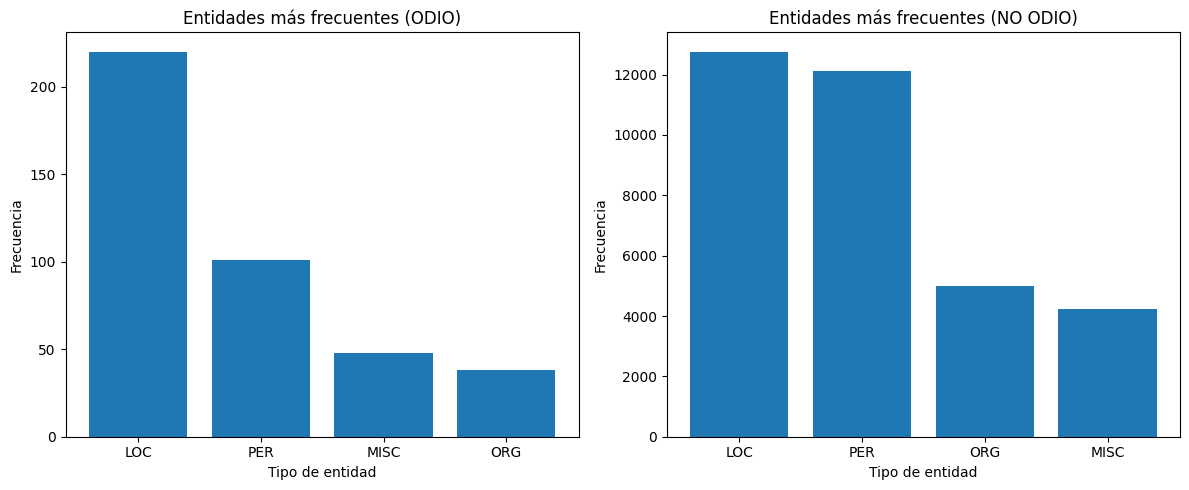

In [ ]:
# =====================================================
# 1. EJEMPLO: DETECCIÓN DE ENTIDADES NER CON SPACY
# =====================================================
texto_prueba = "Apple invertirá dinero en España"

doc = nlp(texto_prueba)

print("################# EJEMPLO DETECCIÓN ENTIDADES NER #################")
print("Texto:", texto_prueba)
print("Entidades detectadas:", [(ent.text, ent.label_) for ent in doc.ents])
print("¿Tiene entidades?:", 1 if len(doc.ents) > 0 else 0)


# =====================================================
# 2. DETECCIÓN DE ENTIDADES EN TODA LA MUESTRA
# =====================================================
print("\n--------------------------------------------------------------------")

# Se crea una columna binaria:
# 1 → tiene al menos una entidad
# 0 → no tiene entidades
data["tiene_entidades"] = data["CONTENIDO A ANALIZAR"].apply(
    lambda x: 1 if len(nlp(str(x)).ents) > 0 else 0
)

# Cálculo del porcentaje por grupo (ODIO vs NO ODIO)
porcentaje_entidades = data.groupby("ODIO")["tiene_entidades"].mean() * 100

print("################# PORCENTAJE DE ENTIDADES NER POR GRUPO #################")
print(porcentaje_entidades)

# Cálculo explícito por grupo
porc_no_odio = data[data["ODIO"] == 0]["tiene_entidades"].mean() * 100
porc_odio = data[data["ODIO"] == 1]["tiene_entidades"].mean() * 100

print("\nDetalle:")
print("No odio (% con entidades):", porc_no_odio)
print("Odio (% con entidades):", porc_odio)


# =====================================================
# 3. IMPORTAR LIBRERÍAS PARA VISUALIZACIÓN
# =====================================================


# =====================================================
# 4. EXTRAER ETIQUETAS DE ENTIDADES (NER)
# =====================================================
# Se obtiene una lista de etiquetas por cada comentario (PER, LOC, ORG, etc.)
data["labels_entidades"] = data["CONTENIDO A ANALIZAR"].apply(
    lambda x: [ent.label_ for ent in nlp(str(x)).ents]
)


# =====================================================
# 5. SEPARAR DATASET EN DOS GRUPOS
# =====================================================
data_odio = data[data["ODIO"] == 1]
data_no_odio = data[data["ODIO"] == 0]


# =====================================================
# 6. APLANAR LISTAS DE ETIQUETAS
# =====================================================
# Convertimos listas de listas en listas simples para contar frecuencias

labels_odio = [
    label
    for sublist in data_odio["labels_entidades"]
    for label in sublist
]

labels_no_odio = [
    label
    for sublist in data_no_odio["labels_entidades"]
    for label in sublist
]


# =====================================================
# 7. CONTAR FRECUENCIA DE ENTIDADES
# =====================================================
conteo_odio = Counter(labels_odio)
conteo_no_odio = Counter(labels_no_odio)


# =====================================================
# 8. SELECCIONAR TOP 5 ENTIDADES MÁS FRECUENTES
# =====================================================
top_odio = dict(conteo_odio.most_common(5))
top_no_odio = dict(conteo_no_odio.most_common(5))


# =====================================================
# 9. VISUALIZACIÓN: GRÁFICAS LADO A LADO
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Gráfico ODIO ----
axes[0].bar(top_odio.keys(), top_odio.values())
axes[0].set_title("Entidades más frecuentes (ODIO)")
axes[0].set_xlabel("Tipo de entidad")
axes[0].set_ylabel("Frecuencia")

# ---- Gráfico NO ODIO ----
axes[1].bar(top_no_odio.keys(), top_no_odio.values())
axes[1].set_title("Entidades más frecuentes (NO ODIO)")
axes[1].set_xlabel("Tipo de entidad")
axes[1].set_ylabel("Frecuencia")

# Ajustar layout
plt.tight_layout()
plt.show()

<b>Para calcular el porcentaje de comentarios que contienen entidades NER en los grupos de odio y no odio, el objeto doc que se crea usando nlp facilita el atributo doc.ents, el cual detecta si el comentario contiene entidades nombradas. Si doc.ents identifica al menos una entidad en el comentario se marca con valor 1, caso contrario con 0. Este resultado se guarda en la nueva columna "tiene_entidades".</b>

<b>Luego los comentarios se agrupan segun la columna "ODIO" creada antes y se calcula el promedio de la columna "tiene_entidades", el cual se multiplica por 100 para obtener el porcentaje de comentarios con entidades NER en cada grupo.</b>

<b>Finalmente, para facilitar la interpretacion de los resultados se extraen las etiquetas de las entidades detectadas utilizando el atributo ent.label_. Estas etiquetas se agrupan segun el tipo de comentario (odio y no odio), se cuentan sus frecuencias y se seleccionan las mas comunes, con esta informacian se generan graficas de barras que permiten visualizar y comparar los tipos de entidades NER frecuentes en cada grupo. Ademas, se incluye un ejemplo inicial, que muestra como spaCy reconoce entidades NER en un texto simple utilizando el modelo de lenguaje entrenado para español descrito en la pregunta 2</b>
<hr>


<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Plantea tus propias preguntas</span>

<span><b>Plantea al menos 4 características</b> del texto cuyo análisis permita una caracterización completa del texto. Puedes utilizar recomendaciones proporcionadas por la IA Generativa, si así lo deseas. Para cada una de las características planteadas, obtén valores separados para los grupos ODIO/NO-ODIO.</span>

<span>En la explicación aportada, deberás <b>explicar el significado de la característica planteada</b> así como la importancia de ésta en la caracterización del texto.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica 1: Proporción de palabras ofensivas / negativas</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Mide la cantidad de palabras negativas u ofensivas en el texto.</span>

In [ ]:
# =====================================================
# 1. LISTA DE PALABRAS NEGATIVAS / OFENSIVAS
# =====================================================
# Lista ampliada basada en lenguaje común en redes sociales
# Incluye insultos, desprecio, agresión verbal y expresiones negativas

palabras_negativas = [
    # insultos directos
    "idiota", "estupido", "estúpido", "imbecil", "imbécil", "tonto", "tonta",
    "tarado", "inutil", "inútil", "ignorante",

    # odio / desprecio
    "odio", "asco", "repugnante", "despreciable", "detestable", "horrible",
    "patetico", "patético", "vergonzoso", "lamentable",

    # agresión verbal
    "basura", "mierda", "maldito", "maldita", "malparido", "malparida",
    "desgraciado", "desgraciada", "infeliz",

    # burlas / humillación
    "ridiculo", "ridículo", "payaso", "payasa", "fracasado", "fracasada",
    "mediocre", "inservible",

    # rechazo social
    "irrelevante",

    # discriminación / ataque
    "asqueroso", "asquerosa", "enfermo", "enferma", "loco", "loca"
]


# =====================================================
# 2. FUNCIÓN PARA CALCULAR PROPORCIÓN DE PALABRAS NEGATIVAS
# =====================================================
def proporcion_negativas(texto):
    """
    Calcula la proporción de palabras negativas en un texto.

    Pasos:
    1. Procesa el texto con spaCy
    2. Filtra tokens válidos (sin signos ni espacios)
    3. Usa lematización para detectar variantes de palabras
    4. Calcula proporción: negativas / total palabras
    """

    # Procesar texto con spaCy y convertir a minúsculas
    doc = nlp(str(texto).lower())

    # Filtrar tokens válidos (solo palabras)
    tokens = [
        token for token in doc
        if not token.is_punct and not token.is_space
    ]

    # Evitar división por cero
    if len(tokens) == 0:
        return 0

    # Contar palabras negativas usando lema (forma base)
    negativas = [
        token for token in tokens
        if token.lemma_ in palabras_negativas
    ]

    # Retornar proporción
    return len(negativas) / len(tokens)


# =====================================================
# 3. APLICAR LA FUNCIÓN AL DATASET
# =====================================================
# Se crea una nueva columna con la proporción de palabras negativas
data["prop_negativas"] = data["CONTENIDO A ANALIZAR"].apply(proporcion_negativas)


# =====================================================
# 4. CALCULAR PROMEDIO POR GRUPO (ODIO vs NO ODIO)
# =====================================================
promedio_negativas = data.groupby("ODIO")["prop_negativas"].mean()

print("################# PROPORCIÓN PROMEDIO DE PALABRAS NEGATIVAS #################")
print(promedio_negativas)


# =====================================================
# 5. RESULTADOS EXPLÍCITOS POR GRUPO
# =====================================================
prom_no_odio = data[data["ODIO"] == 0]["prop_negativas"].mean()
prom_odio = data[data["ODIO"] == 1]["prop_negativas"].mean()

print("\nDetalle:")
print("No odio (proporción promedio):", prom_no_odio)
print("Odio (proporción promedio):", prom_odio)

promedio_negativas_pct = promedio_negativas * 100

print("Proporción promedio de palabras negativas (%)")
print(promedio_negativas_pct)

# =====================================================
# 6. EJEMPLO DE VALIDACIÓN
# =====================================================
texto_prueba = "Eres un idiota, persona horrible y asquerosa"

doc = nlp(texto_prueba.lower())

tokens_validos = [
    token.text for token in doc
    if not token.is_punct and not token.is_space
]

negativas_detectadas = [
    token.text for token in doc
    if token.lemma_ in palabras_negativas
]

print("\n################# VALIDACIÓN #################")
print("Texto:", texto_prueba)
print("Tokens válidos:", tokens_validos)
print("Palabras negativas detectadas:", negativas_detectadas)
print("Proporción:", proporcion_negativas(texto_prueba))

################# PROPORCIÓN PROMEDIO DE PALABRAS NEGATIVAS #################
ODIO
0    0.002654
1    0.044990
Name: prop_negativas, dtype: float64

Detalle:
No odio (proporción promedio): 0.002653742160699421
Odio (proporción promedio): 0.044989770023452766
Proporción promedio de palabras negativas (%)
ODIO
0    0.265374
1    4.498977
Name: prop_negativas, dtype: float64

################# VALIDACIÓN #################
Texto: Eres un idiota, persona horrible y asquerosa
Tokens válidos: ['eres', 'un', 'idiota', 'persona', 'horrible', 'y', 'asquerosa']
Palabras negativas detectadas: ['idiota', 'horrible', 'asquerosa']
Proporción: 0.42857142857142855


<b>Esta caracteristica sirve para medir que tanto contenido negativo tiene un comentario, contando cuantas palabras ofensivas o negativas aparecen en el texto en relacion con el total de palabras, la idea es que los comentarios de odio suelen usar mas insultos o expresiones agresivas, por lo que esta medida ayuda bastante en tareas como deteccian de odio y analisis de toxicidad en redes sociales como Facebook e Instagram, entre otras.</b>

<b>Para el analisis de palabras negativas, primero se define una lista de terminos ofensivos y negativos basada en expresiones comunes en redes sociales, esta lista incluye insultos directos, expresiones de desprecio, agresion verbal y palabras asociadas a burlas o rechazo social, la finalidad de esta lista es contar con un vocabulario de referencia que permita detectar lenguaje negativo de forma explicita dentro de los textos que se van a analizar, ojo que esta lista solo es una pequeña proporcion de datos para una prueba de concepto en esta pregunta, en una escala mas real se usaria un dataset mucho mas completo.</b>

<b>En vista que ya he usado pyhton antes, opte que el codigo generado sea mas modular para separar mejor las responsabilidades y que el este sea mas facil de entender en las 4 caracteristicas adicionales que se proponen.</b>

<b>Se define la funcion proporcion_negativas, esta se utiliza para encapsular todo el proceso de analisis en una sola estructura reutilizable. El uso de esta funcion permite aplicar el mismo procedimiento a cada texto del dataset. Dentro de esta funcion el texto se procesa con el modelo de lenguaje nlp de spaCy explicado al inicio, y se convierte a minusculas para evitar diferencias entre mayusculas y minusculas durante la comparacion de palabras. <b/>

<b>Una vez procesado el texto, se filtran los tokens utilizando los atributos is_punct e is_space, con el objetivo de excluir signos de puntuacion y espacios, y asi trabajar unicamente con palabras reales. Este filtrado es importante para que el conteo sea mas preciso. Ademas se incluye una validacion para evitar divisiones por cero en casos donde el texto no contenga palabras validas y retorna un valor de 0, para evitar que el proceso se interrumpa por inconsistencia de datos. </b>

<b>Para identificar las palabras negativas, se utiliza el atributo lemma_, el cual nos ayuda a trabajar con la forma base de cada palabra. La lematizacion es importante porque posibilita detectar diferentes variantes de una palabra (por ejemplo, masculino, femenino o plural) como una misma categoria semantica. Con esto se busca que la deteccion de lenguaje negativo sea mas preciso y menos dependiente de la forma exacta en la que aparece el termino en el texto. Esta implementacion ayuda a comprender mejor el material visto de los temas 1 y 2 de la materia PLN.</b>

<b>La funcion retorna la proporcion de palabras negativas calculada, para esto se divide la cantidad de palabras negativas detectadas entre el total de palabras validas del texto. La idea detras de esto es que permita normalizar el conteo y comparar textos de diferente longitud de manera justa. La funcion se aplica a toda la columna "CONTENIDO A ANALIZAR" mediante apply ya explicada antes, generando una nueva columna llamada "prop_negativas" que almacena la proporcion individual de cada comentario.</b>

<b>Finalmente, los resultados se agrupan segun la variable "ODIO" creada antes, y se calcula el promedio de la proporcion de palabras negativas en cada grupo. </b>

<b>Al analizar los resultados, se observa que los comentarios sin odio casi no usan palabras negativas (alrededor de 0.27%), mientras que los comentarios con odio tienen una proporcion mucho mayor (cerca del 4.5%). Esto confirma que esta caracteristica es bastante util para diferenciar entre ambos tipos de comentarios.</b>

<b>Ademas de esto, se incluye un ejemplo de validacion que permite observar de forma mas clara como spaCy tokeniza el texto, que palabras son consideradas validas y cuales son identificadas como negativas segun la lista definida.</b>

<hr>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica 2: Longitud promedio de palabras</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Mide el tamaño promedio (en número de caracteres) de las palabras en cada comentario.</span>

In [ ]:
# =====================================================
# 1. FUNCIÓN: LONGITUD PROMEDIO DE PALABRAS
# =====================================================
def longitud_promedio_palabras(texto):
    """
    Calcula la longitud promedio de palabras en un comentario.

    Pasos:
    1. Procesa el texto con spaCy
    2. Filtra tokens válidos (sin signos ni espacios)
    3. Calcula el tamaño de cada palabra
    4. Obtiene el promedio de caracteres
    """

    doc = nlp(str(texto))

    # Filtrar solo palabras válidas
    tokens = [
        token.text for token in doc
        if not token.is_punct and not token.is_space
    ]

    # Evitar división por cero
    if len(tokens) == 0:
        return 0

    # Calcular promedio de longitud
    return sum(len(palabra) for palabra in tokens) / len(tokens)


# =====================================================
# 2. APLICAR AL DATASET
# =====================================================
data["longitud_prom_palabras"] = data["CONTENIDO A ANALIZAR"].apply(
    longitud_promedio_palabras
)


# =====================================================
# 3. PROMEDIO POR GRUPO (ODIO vs NO ODIO)
# =====================================================
promedio_longitud = data.groupby("ODIO")["longitud_prom_palabras"].mean()

print("################# LONGITUD PROMEDIO DE PALABRAS #################")
print(promedio_longitud)


# =====================================================
# 4. RESULTADOS DETALLADOS
# =====================================================
prom_no_odio = data[data["ODIO"] == 0]["longitud_prom_palabras"].mean()
prom_odio = data[data["ODIO"] == 1]["longitud_prom_palabras"].mean()

print("\nDetalle:")
print("No odio (longitud promedio):", prom_no_odio)
print("Odio (longitud promedio):", prom_odio)


# =====================================================
# 5. EJEMPLO DE VALIDACIÓN
# =====================================================
texto_prueba = "Eres una persona absolutamente desagradable"

doc = nlp(texto_prueba)

tokens = [
    token.text for token in doc
    if not token.is_punct and not token.is_space
]

longitudes = [len(p) for p in tokens]

print("\n################# VALIDACIÓN #################")
print("Texto:", texto_prueba)
print("Palabras:", tokens)
print("Longitud de cada palabra:", longitudes)
print("Promedio:", sum(longitudes) / len(longitudes))

################# LONGITUD PROMEDIO DE PALABRAS #################
ODIO
0    5.069252
1    5.272575
Name: longitud_prom_palabras, dtype: float64

Detalle:
No odio (longitud promedio): 5.0692523548173325
Odio (longitud promedio): 5.272575288133219

################# VALIDACIÓN #################
Texto: Eres una persona absolutamente desagradable
Palabras: ['Eres', 'una', 'persona', 'absolutamente', 'desagradable']
Longitud de cada palabra: [4, 3, 7, 13, 12]
Promedio: 7.8




<b>Esta caracteristica mide el tamaño promedio de las palabras contando cuantos caracteres tiene cada una. Sirve para entender mejor el estilo de escritura ya que un lenguaje mas simple suele usar palabras cortas, mientras que un lenguaje mas elaborado tiende a usar palabras mas largas, como cuando alguien insulta en redes se entenderia que usa frases mas largas para expresarse usando adjetivos descriptivos y terminos negativos. </b>


<b>Para analizar la longitud promedio de las palabras se define la funcion longitud_promedio_palabras, la cual se encarga de calcular el promedio de longitud de las palabras de un texto como ya se habia hecho en las preguntas anteriores, para que este calculo sea mas preciso se deben excluir signos de puntuacion y espacios utilizando los atributos is_punct e is_space, tambien se implementa la validacion para evitar errores de division por cero en los casos en que un comentario no contenga palabras validas y solo devuelve 0 si se da el caso. Luego se obtiene el numero de caracteres de cada palabra usando la función len(), se suman todas las longitudes y este valor se divide entre el numero total de palabras del comentario.</b>


<b>La funcion se aplica a toda la columna "CONTENIDO A ANALIZAR" mediante el metodo apply, lo que permite ejecutar el mismo calculo para cada fila del dataset. El resultado se almacena en una nueva columna llamada "longitud_prom_palabras", la cual contiene la longitud promedio de palabras para cada comentario.</b>


<b>Finalmente, los resultados se agrupan segun la variable ODIO y se calcula el promedio de la longitud de palabras en cada grupo. </b>

<b>Los resultados muestran que ambos grupos tienen longitudes de palabras bastante similares, aunque los comentarios con odio presentan un promedio ligeramente mayor (5.27 caracteres) frente a los comentarios sin odio (5.07 caracteres). Esto indica que en la muestra tomada del dataset, la caracteristica no marca una diferencia muy significativa, pero igual aporta informacion sobre el estilo del lenguaje.<b>

<b> Adenas tambien se incluye el ejemplo de validacion que confirma que el calculo funciona correctamente, ya que textos con palabras mas largas generan promedios mas altos.</b>
<hr>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica 3: Uso de MAYÚSCULAS</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Mide la cantidad (o proporción) de palabras escritas completamente en MAYÚSCULAS.</span>

In [ ]:
# =====================================================
# 1. FUNCIÓN: PROPORCIÓN DE PALABRAS EN MAYÚSCULAS
# =====================================================
def proporcion_mayusculas(texto):
    """
    Calcula la proporción de palabras en mayúsculas.

    Pasos:
    1. Procesa el texto con spaCy
    2. Filtra tokens válidos
    3. Detecta palabras completamente en mayúsculas
    4. Calcula proporción respecto al total
    """

    doc = nlp(str(texto))

    # Filtrar palabras válidas
    tokens = [
        token.text for token in doc
        if not token.is_punct and not token.is_space
    ]

    if len(tokens) == 0:
        return 0

    # Detectar palabras en MAYÚSCULAS
    mayusculas = [
        t for t in tokens
        if t.isupper() and len(t) > 1  # evitar contar "A"
    ]

    return len(mayusculas) / len(tokens)


# =====================================================
# 2. APLICAR AL DATASET
# =====================================================
data["prop_mayusculas"] = data["CONTENIDO A ANALIZAR"].apply(
    proporcion_mayusculas
)


# =====================================================
# 3. PROMEDIO POR GRUPO
# =====================================================
promedio_mayusculas = data.groupby("ODIO")["prop_mayusculas"].mean()

print("################# PROPORCIÓN DE MAYÚSCULAS #################")
print(promedio_mayusculas)


# =====================================================
# 4. RESULTADOS DETALLADOS (EN %)
# =====================================================
prom_no_odio = data[data["ODIO"] == 0]["prop_mayusculas"].mean() * 100
prom_odio = data[data["ODIO"] == 1]["prop_mayusculas"].mean() * 100

print("\nDetalle (%):")
print("No odio (% mayúsculas):", prom_no_odio)
print("Odio (% mayúsculas):", prom_odio)


# =====================================================
# 5. EJEMPLO DE VALIDACIÓN
# =====================================================
texto_prueba = "ERES un IDIOTA total y esto es HORRIBLE"

doc = nlp(texto_prueba)

tokens = [
    token.text for token in doc
    if not token.is_punct and not token.is_space
]

mayusculas = [
    t for t in tokens
    if t.isupper() and len(t) > 1
]

print("\n################# VALIDACIÓN #################")
print("Texto:", texto_prueba)
print("Tokens:", tokens)
print("Palabras en MAYÚSCULAS:", mayusculas)
print("Proporción:", proporcion_mayusculas(texto_prueba))

################# PROPORCIÓN DE MAYÚSCULAS #################
ODIO
0    0.025677
1    0.019391
Name: prop_mayusculas, dtype: float64

Detalle (%):
No odio (% mayúsculas): 2.5676734827294583
Odio (% mayúsculas): 1.9390893626054937

################# VALIDACIÓN #################
Texto: ERES un IDIOTA total y esto es HORRIBLE
Tokens: ['ERES', 'un', 'IDIOTA', 'total', 'y', 'esto', 'es', 'HORRIBLE']
Palabras en MAYÚSCULAS: ['ERES', 'IDIOTA', 'HORRIBLE']
Proporción: 0.375



<b>Esta caracteristica mide que tanto se usan palabras escritas completamente en mayusculas dentro de un comentario, la idea detras de esto es que en redes sociales o chats escribir en mayusculas normalmente significa que la persona esta gritando con enojo o quiere enfatizar algo, lo cual muchas veces esta relacionado con comentarios agresivos u ofensivos</b>

<b>Para analizar esta caracteristica se define la funcion proporcion_mayusculas, esta se encarga de calcular la proporcion de palabras en mayusculas presentes en un texto. Al igual que en los analisis anteriores, el texto se procesa utilizando spaCy y se excluyen los signos de puntuacion y los espacios mediante los atributos is_punct e is_space, con el fin de trabajar unicamente con palabras validas y asegurar que el calculo sea mas preciso.</b>

<b>Una vez obtenidos los tokens validos se identifican las palabras que estan completamente en mayusculas utilizando el metodo isupper(). Ademas se añade la condicion de que la longitud de la palabra sea mayor a un caracter para evitar contar letras aisladas como “A”, las cuales no representan un uso real de mayusculas con intencion expresiva, tambien se incluye una validacion para evitar errores de division por cero en los casos en que el comentario no contenga palabras validas.</b>

<b>La proporcion de palabras en mayusculas se calcula dividiendo el numero de palabras detectadas en mayusculas entre el total de palabras del comentario. Este enfoque permite normalizar el valor y comparar textos de distinta longitud de manera justa, la funcion se aplica a toda la columna "CONTENIDO A ANALIZAR" mediante el metodo apply, generando una nueva columna llamada "prop_mayusculas" que almacena la proporción correspondiente a cada comentario<b>

<b>Finalmente, los resultados se agrupan segun la variable "ODIO" y se calcula el promedio de la proporcion de mayusculas para cada grupo.</b>

<b>Los resultados muestran que los comentarios sin odio tienen un porcentaje inferior (2.5%) a los que se clasifican con odio (1.9%). Esto sugiere que esta caracteristica no nos sirve para validar que un comentario que tenga mas mayusculas sea precisamente de odio, se puede intuir que tambien pueden estar expresando otras emociones como alegria o euforia.</b>

<b>Adenas tambien se incluye un ejemplo de validacion que ayuda a entender mejor el calculo, ya que en el texto de prueba varias palabras estan en mayusculas y se obtiene una proporcion alta (37.5%), lo cual coincide con un mensaje escrito de forma agresiva y enfatizada, pero tambien puede dar el mismo resultado con un mensaje que exprese alegria o euforia.</b>
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica 4: Densidad de adjetivos</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Mide la proporción de adjetivos dentro del texto.</span>

In [ ]:
# =====================================================
# 1. FUNCIÓN: PROPORCIÓN DE ADJETIVOS
# =====================================================
def proporcion_adjetivos(texto):
    """
    Calcula la proporción de adjetivos en un comentario.

    Pasos:
    1. Procesa el texto con spaCy
    2. Filtra tokens válidos
    3. Identifica adjetivos usando POS tagging
    4. Calcula proporción respecto al total
    """

    doc = nlp(str(texto))

    # Filtrar palabras válidas
    tokens = [
        token for token in doc
        if not token.is_punct and not token.is_space
    ]

    if len(tokens) == 0:
        return 0

    # Detectar adjetivos (POS = ADJ)
    adjetivos = [
        token for token in tokens
        if token.pos_ == "ADJ"
    ]

    return len(adjetivos) / len(tokens)


# =====================================================
# 2. APLICAR AL DATASET
# =====================================================
data["prop_adjetivos"] = data["CONTENIDO A ANALIZAR"].apply(
    proporcion_adjetivos
)


# =====================================================
# 3. PROMEDIO POR GRUPO (ODIO vs NO ODIO)
# =====================================================
promedio_adjetivos = data.groupby("ODIO")["prop_adjetivos"].mean()

print("################# PROPORCIÓN DE ADJETIVOS #################")
print(promedio_adjetivos)


# =====================================================
# 4. RESULTADOS DETALLADOS EN %
# =====================================================
prom_no_odio = data[data["ODIO"] == 0]["prop_adjetivos"].mean() * 100
prom_odio = data[data["ODIO"] == 1]["prop_adjetivos"].mean() * 100

print("\nDetalle (%):")
print("No odio (% adjetivos):", prom_no_odio)
print("Odio (% adjetivos):", prom_odio)


# =====================================================
# 5. EJEMPLO DE VALIDACIÓN
# =====================================================
texto_prueba = "Eres una persona horrible y completamente ridícula"

doc = nlp(texto_prueba)

tokens = [
    token.text for token in doc
    if not token.is_punct and not token.is_space
]

adjetivos = [
    token.text for token in doc
    if token.pos_ == "ADJ"
]

print("\n################# VALIDACIÓN #################")
print("Texto:", texto_prueba)
print("Tokens:", tokens)
print("Adjetivos detectados:", adjetivos)
print("Proporción:", proporcion_adjetivos(texto_prueba))

################# PROPORCIÓN DE ADJETIVOS #################
ODIO
0    0.072713
1    0.136358
Name: prop_adjetivos, dtype: float64

Detalle (%):
No odio (% adjetivos): 7.271315244941964
Odio (% adjetivos): 13.635820692860056

################# VALIDACIÓN #################
Texto: Eres una persona horrible y completamente ridícula
Tokens: ['Eres', 'una', 'persona', 'horrible', 'y', 'completamente', 'ridícula']
Adjetivos detectados: ['horrible', 'ridícula']
Proporción: 0.2857142857142857


<b>Esta caracteristica mide la proporción de adjetivos que aparecen en un comentario en relacion con el total de palabras. La idea es que los adjetivos suelen usarse para dar opiniones o hacer juicios, por ejemplo cuando se califica a alguien o algo de forma positiva o negativa, lo cual es muy comun en comentarios de odio sobre todo en redes sociales.</b>

<b>Para realizar este analisis se define la funcion proporcion_adjetivos, la cual sirve para calcular de manera sencilla y ordenada la proporcion de adjetivos en cada comentario, como en los analisis anteriores el texto se procesa con spaCy para poder trabajar con informacion lingüistica mas detallada de cada palabra.</b>

<b>Una vez procesado el texto, se filtran los tokens utilizando los atributos is_punct e is_space excluyendo signos de puntuacion y espacios, esto permite trabajar unicamente con palabras reales y evita que el conteo se vea alterado por elementos que no aportan contenido lingüistico. Tambien se incluye una validacion para evitar errores en los casos en que un comentario no contenga palabras validas y solo retorne 0.</b>

<b>La identificacion de los adjetivos se realiza usando el atributo pos_, el cual nos ayuda a identificar la categoria gramatical de cada palabra, en este caso se seleccionan unicamente los tokens etiquetados como “ADJ”, lo que permite detectar directamente los adjetivos presentes en el texto sin necesidad de definir reglas manuales.</b>

<b>La proporcion de adjetivos se obtiene dividiendo la cantidad de adjetivos detectados entre el total de palabras del comentario, de esta manera el valor queda normalizado y se pueden comparar comentarios de diferentes longitudes. Esta funcion se aplica a toda la columna "CONTENIDO A ANALIZAR" mediante apply, generando una nueva columna llamada "prop_adjetivos" que almacena el resultado para cada comentario.</b>

<b>Los resultados se agrupan segun la variable ODIO y se calcula el promedio de la proporcion de adjetivos para cada grupo. </b>

<b>Los resultados muestran que, los comentarios sin odio tienen en promedio alrededor de 7.27% de adjetivos, mientras que los comentarios con odio alcanzan aproximadamente 13.64%. Esto sugiere que los comentarios de odio tienden a usar mas adjetivos, lo que refleja un lenguaje cargado de juicios, muchas veces negativos.</b>

<b>Adenas tambien se incluye un ejemplo de validacion, que ayuda a confirmar el calculo, ya que en el texto de prueba se detectan claramente los adjetivos “horrible” y “ridícula” obteniendo una proporcion alta (28.6%). Es importante tener en cuenta que esta caracteristica mide subjetividad pero no distingue si los adjetivos son positivos o negativos por lo que debe analizarse junto con otras metricas.</b>
<hr>


<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Reflexión final</span>

<span>Una de las utilidades de la caracterización de texto es que nos sirve como etapa de <i>feature-extraction</i> (extración de características) de cara a un posterior sistema de clasificación. Es pertinente, por tanto, reflexionar sobre la capacidad discriminatoria de cada una de las características extraídas. </span>

<span> Responde, para ello, a la siguiente pregunta.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Reflexión final.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Es posible utilizar alguna de las características extraídas en las preguntas anteriores para determinar si un mensaje contiene odio? Justifica tu respuesta con el análisis estadístico que consideres necesario.</span>

In [ ]:
# Incluye aquí el código generado para poder responder a tu pregunta


<b>Sí, sí es posible utilizar algunas de estas características para detectar si un mensaje es de odio, pero no todas nos darán una respuesta clara, ya que sus metricas pueden ser algo ambiguas y no siempre es facil detectar si hay odio. Por ello seria importante complementarlas para obtener un mejor resultado.</b>

<b>Por ejemplo, en la caracteristica que mide las palabras ofensivas o negativas en un comentario, segun los resultados obtenidos los comentarios sin odio casi no usan palabras negativas, en este caso un 0.27% mientras que en los comentarios con odio si se observa un porcentaje mucho mas alto con un 4.5%. De igual forma la caracteristica que mide la proporcion de adjetivos en un texto muestra que los comentarios sin odio tienen un promedio de 7.27%, mientras que los comentarios con odio alcanzan un 28.6%. Esto confirma que en los comentarios con odio se tiende a usar mas adjetivos los cuales pueden expresar juicios o calificativos negativos.</b>

<b>Sin embargo si nos centramos en la caracteristica del uso de mayusculas se podria pensar que estas se utilizan para expresar ira o enojo de una manera mas enfática. Pero segun los resultados obtenidos con la muestra tomada, el mayor porcentaje se presenta en los comentarios sin odio con un 2.57%, frente a un 1.94% en los comentarios con odio. Esto sugiere que el uso de mayusculas no necesariamente implica odio o ira, sino que puede representar otro tipo de emocion como alegria por ejemplo, por lo que esta metrica resulta ambigua para identificar o agrupar comentarios con o son odio.</b>

<b>Como conclusion, las caracteristicas revisadas si se pueden utilizar para determinar si un mensaje o texto contiene odio, pero es recomendable complementarlas entre si para obtener un resultado mas preciso y evitar falsos positivos, finalmente para aclarar, los resultados descritos anteriormente se tomaron de una muestra del dataset completo, por lo que no pueden estar muy apegados a la realidad, de igual manera, estos nos dan una breve idea de como se podria analizar textos y detectar odio u otras emociones segun sea el objetivo. </b>

<hr>


